# Hourly Delay Profile

Shows the local hours when buses are most late.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "hourly_delay_profile",
    PROJECT_ROOT / "analysis" / "hourly-delay-profile.py",
)
hourly = importlib.util.module_from_spec(spec)
spec.loader.exec_module(hourly)

DB = PROJECT_ROOT / "data" / "foli.db"
TIMEZONE = "Europe/Helsinki"
LINE_REF = None
MIN_OBSERVATIONS = 30
LIMIT = 24
QUALITY_MODE = "conservative"
BUCKET = "trip-stop"

In [2]:
class Args:
    db = DB
    timezone = TIMEZONE
    line_ref = LINE_REF
    min_observations = MIN_OBSERVATIONS
    limit = LIMIT
    quality_mode = QUALITY_MODE
    exclude_stop_call_disagreement = False
    bucket = BUCKET

df = hourly.load_observations(Args)
profile = hourly.build_profile(Args, df)
profile

,hour_local,bucket_count,raw_poll_count,signed_mean_delay_min,median_delay_min,p75_delay_min,p90_delay_min,p95_delay_min,pct_over_3_min_late,pct_over_5_min_late,pct_early,pct_over_1_min_early,pct_over_3_min_early
0,15:00,141140,377516,0.95,0.50,2.23,4.58,6.42,18.34,8.60,36.22,18.66,5.66
1,16:00,133864,348649,0.91,0.42,2.12,4.48,6.28,17.69,8.10,37.61,19.29,5.29
2,14:00,132401,359401,0.60,0.26,1.74,3.77,5.57,14.02,6.01,40.35,21.04,6.14
3,13:00,116522,312177,0.56,0.28,1.70,3.62,5.25,13.22,5.47,39.45,20.72,6.53
4,12:00,103334,275904,0.45,0.18,1.48,3.23,4.78,11.23,4.59,41.18,21.05,5.90
5,17:00,122101,317585,0.04,-0.02,1.12,2.98,4.71,9.86,4.48,50.11,28.38,9.14
6,08:00,132500,350365,0.13,0.00,1.22,2.90,4.33,9.51,3.72,46.64,24.98,7.83
7,11:00,98859,267043,0.18,0.12,1.33,2.83,4.07,9.02,3.02,43.23,22.56,7.00
8,19:00,90956,231148,0.27,0.09,1.24,2.80,4.13,8.91,3.50,43.51,22.16,6.26
9,18:00,104358,268638,0.01,0.00,1.12,2.73,4.41,8.79,4.06,47.73,26.38,9.17


Delay has positive and negative values. Positive values mean that bus is is late. Negative value means bus is early.

Text(0, 0.5, 'P90 delay, minutes')

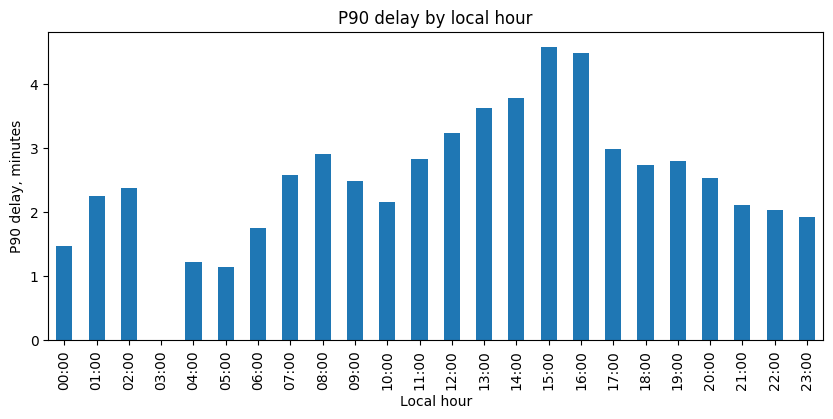

In [3]:
ax = profile.sort_values("hour_local").plot.bar(
    x="hour_local",
    y="p90_delay_min",
    legend=False,
    figsize=(10, 4),
    title="P90 delay by local hour",
)
ax.set_xlabel("Local hour")
ax.set_ylabel("P90 delay, minutes")